# Simple Visualizer for S2 datasets

In [1]:
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_example_image(path, plot=True):
    """
    Loads example Sentinel-2 image from path to tif file
    :param path: Path to image file
    :param plot: If True, will plot an RGB image of the satellite image
    :return: Normalized image as torch tensor
    """
    with rasterio.open(path) as f:
            data = f.read().astype(np.float32)
            image = data / 10000.0
            B10 = np.zeros((1, *image.shape[1:]), dtype=image.dtype)
            image = np.concatenate([image[:10], B10, image[10:]], axis=0)
            image = torch.tensor(image)

            if plot:
                    # Read the first three RGB bands (assuming they are bands 4, 3, and 2)
                    red_band = f.read(4) / 10000.0
                    green_band = f.read(3) / 10000.0
                    blue_band = f.read(2) / 10000.0

                    # Stack the bands to create an RGB image
                    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

                    # Plot the RGB image
                    plt.imshow(rgb_image)
                    plt.title("RGB Sentinel-2 Image")
                    plt.axis('off')  # Hide axes
                    plt.show()

    return image


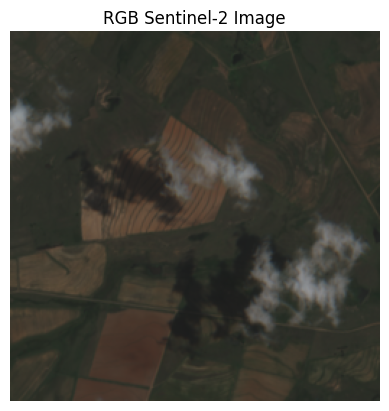

In [2]:
img = get_example_image("/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_50004.tif", plot=True)

In [ ]:
import pandas as pd
import os
from tqdm import tqdm

# Iterate through dataset to check for corrupted files
CHECK_MIN_FILESIZE = 1000  # in bytes
n_skipped_files = 0

# root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k"
root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip"

index_fn = "index.csv"

df = pd.read_csv(os.path.join(root, index_fn))
filenames = []
points = []

n_skipped_files = 0
n_corrupted_files = 0
for i in tqdm(range(df.shape[0])):
    filename = os.path.join(root, "images", df.iloc[i]["fn"])
    
    # Useful for training subsets
    if os.path.exists(filename) == False:
        n_skipped_files += 1
        continue

    if os.path.getsize(filename) < CHECK_MIN_FILESIZE:
        n_skipped_files += 1
        continue
    
    # Ensure it is valid raster
    try:
        
        with rasterio.open(filename) as f:
            data = f.read().astype(np.float32)
    except:
        n_skipped_files += 1
        n_corrupted_files += 1
        print(f"Corrupted file: {filename}")
        continue

    filenames.append(filename)
    points.append(
        (df.iloc[i]["lon"], df.iloc[i]["lat"])
    )

print(f"Number of skipped files: {n_skipped_files}")

 10%|▉         | 9640/100000 [03:28<02:01, 741.70it/s] 

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_9384.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_9385.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_9386.tif


 24%|██▎       | 23735/100000 [08:23<25:18, 50.24it/s]  

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_23728.tif


 39%|███▉      | 39193/100000 [13:51<20:50, 48.61it/s]

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_39187.tif


 96%|█████████▋| 96351/100000 [33:52<00:00, 7073.05it/s]

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93836.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93837.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93838.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93839.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93841.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93842.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93843.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93844.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93845.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k/images/patch_93846.tif
Corrupted file: /mnt

100%|██████████| 100000/100000 [34:11<00:00, 48.75it/s] 

Number of skipped files: 5870
